In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt



In [13]:
df = pd.read_csv('surat_uncleaned.csv')


print(df.head())
print(df.info())
null_counts = df.isnull().sum()
print(null_counts)

                                       property_name areaWithType square_feet  \
0          2 BHK Apartment for Sale in Dindoli Surat  Carpet Area    644 sqft   
1           2 BHK Apartment for Sale in Althan Surat   Super Area   1278 sqft   
2          2 BHK Apartment for Sale in Pal Gam Surat   Super Area   1173 sqft   
3     2 BHK Apartment for Sale in Jahangirabad Surat  Carpet Area    700 sqft   
4  2 BHK Apartment for Sale in Orchid Fantasia, P...   Super Area   1250 sqft   

       transaction            status        floor      furnishing  \
0     New Property  Poss. by Oct '24  5 out of 10     Unfurnished   
1     New Property  Poss. by Jan '26  6 out of 14     Unfurnished   
2           Resale     Ready to Move  5 out of 13  Semi-Furnished   
3     New Property     Ready to Move  6 out of 14     Unfurnished   
4  Orchid Fantasia      New Property  Unfurnished               2   

        facing                                        description  \
0         West  Luxury projec

In [14]:
df.replace(['-', 'NA', 'N/A', '?', 'xx', '--', 'nan'], np.nan, inplace=True)


def clean_number(col):
    return (
        df[col]
        .astype(str)
        .str.replace('[^0-9.]', '', regex=True)
        .str.strip()
    )

num_cols = ['square_feet', 'price_per_sqft', 'price']

for col in num_cols:
    df[col] = clean_number(col)
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [15]:
df['floor_cleaned'] = (
    df['floor']
    .astype(str)
    .str.extract('(\d+)')
    .astype(float)
)
df['floor_cleaned'] = df['floor_cleaned'].replace({
    'Basement': 0,
    'basement': 0,
    'Basement Floor': 0,
    'Ground': 1,
    'Ground Floor': 1,
    'ground': 1,
})



<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1851459495.py:4: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


In [16]:
valid_furnishing = ['Unfurnished', 'Semi-Furnished', 'Furnished']
valid_facings = [
    'East', 'West', 'North', 'South',
    'North-East', 'South-East', 'North-West', 'South-West',
    'Main Road', 'Garden Facing'
]
valid_transactions = ['New Property', 'Resale']
valid_status = ['Ready to Move', 'Under Construction']

df['transaction'] = df['transaction'].where(df['transaction'].isin(valid_transactions), np.nan)

def clean_row(row):
    f = str(row['furnishing']).strip()
    fa = str(row['facing']).strip()

    if f not in valid_furnishing:
        if f in valid_facings:
            row['facing'] = f
            row['furnishing'] = None
        elif f.replace('.', '', 1).isdigit() or len(f) < 3:
            row['furnishing'] = None
        elif ' ' in f or (f.isalpha() and f not in valid_furnishing):
            row['furnishing'] = None

    if fa not in valid_facings:
        if fa in valid_furnishing:
            row['furnishing'] = fa
            row['facing'] = None
        elif fa.replace('.', '', 1).isdigit() or len(fa) < 3:
            row['facing'] = None
        elif ' ' in fa or (fa.isalpha() and fa not in valid_facings):
            row['facing'] = None

    return row

df = df.apply(clean_row, axis=1)

def clean_status(value):
    value = str(value).strip()
    if value in valid_status:
        return value
    elif value.startswith("Poss. by"):
        return value
    else:
        return np.nan

df['status'] = df['status'].apply(clean_status)

df.reset_index(drop=True, inplace=True)
df.loc[df['furnishing'] == 'Garden/Park', ['furnishing', 'facing']] = [np.nan, 'Garden Facing']
null_counts = df.isnull().sum()
print(null_counts)

property_name        0
areaWithType         0
square_feet          6
transaction        842
status             330
floor               45
furnishing        1255
facing            2560
description       1371
price_per_sqft     368
price              173
floor_cleaned      839
dtype: int64


In [17]:

cat_cols = ['transaction', 'status', 'furnishing', 'facing']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.dropna(subset=['price'], inplace=True)
df.dropna(subset=['square_feet'], inplace=True)

df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())
df['floor_cleaned'] = df['floor_cleaned'].fillna(df['floor_cleaned'].median())

df.drop(columns=['description'], inplace=True, errors='ignore')
df.drop(columns=['floor'], inplace=True, errors='ignore')
df['floor_cleaned'] = df['floor_cleaned'].astype(int)
print(df['floor_cleaned'].unique())


[ 5  6  7  3  1  4  2  9 12 10 13 14  8 16 11 59 15 18 20 17 19]


In [18]:
print(df['facing'].head(50))
print(df.value_counts().sum())
null_counts = df.isnull().sum()
print(null_counts)
print(df.describe())
print(df['square_feet'].unique()[:20])
df.rename(columns={
    'price': 'price (₹ Lac)',
    'price_per_sqft': 'price_per_sqft (₹)'
}, inplace=True)
print(df.info())



0            West
1            East
2            East
3            East
4            East
5            East
6            East
7            East
8            East
9            East
10           East
11           East
12           East
13           East
14           East
15           East
16           East
17           East
18           East
19           East
20           East
21           West
22           East
23           West
24           East
25           East
26           East
27           East
28           East
29           East
30           East
31           East
32           East
33           East
34           East
35           East
36           East
37    Garden/Park
38           East
39           East
40           East
41      Main Road
42           East
43           East
44           East
45           East
46           East
47           East
48           East
49           East
Name: facing, dtype: object
4346
property_name     0
areaWithType      0
square_feet       0
transac

In [19]:
# le = LabelEncoder()
# df['furnishing_encoded'] = le.fit_transform(df['furnishing'])

# df = pd.get_dummies(df, columns=['transaction'], drop_first=True)

# print(df.head())

In [20]:
df = df.drop_duplicates()
df.info()
print(df.head(50))



<class 'pandas.core.frame.DataFrame'>
Index: 4212 entries, 0 to 4517
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_name       4212 non-null   object 
 1   areaWithType        4212 non-null   object 
 2   square_feet         4212 non-null   float64
 3   transaction         4212 non-null   object 
 4   status              4212 non-null   object 
 5   furnishing          4212 non-null   object 
 6   facing              4212 non-null   object 
 7   price_per_sqft (₹)  4212 non-null   float64
 8   price (₹ Lac)       4212 non-null   float64
 9   floor_cleaned       4212 non-null   int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 362.0+ KB
                                        property_name areaWithType  \
0           2 BHK Apartment for Sale in Dindoli Surat  Carpet Area   
1            2 BHK Apartment for Sale in Althan Surat   Super Area   
2           2 BHK Apartment for Sale

In [21]:
df.to_csv('clean_data.csv', index=False)

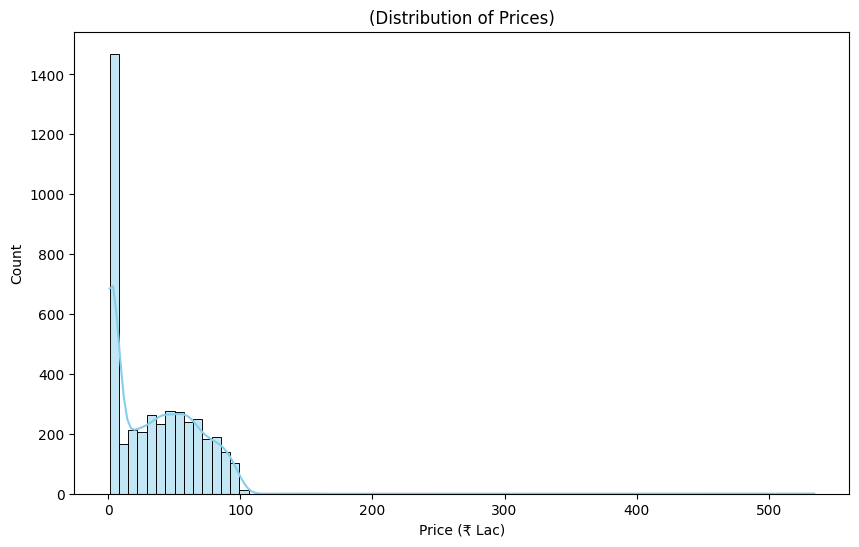

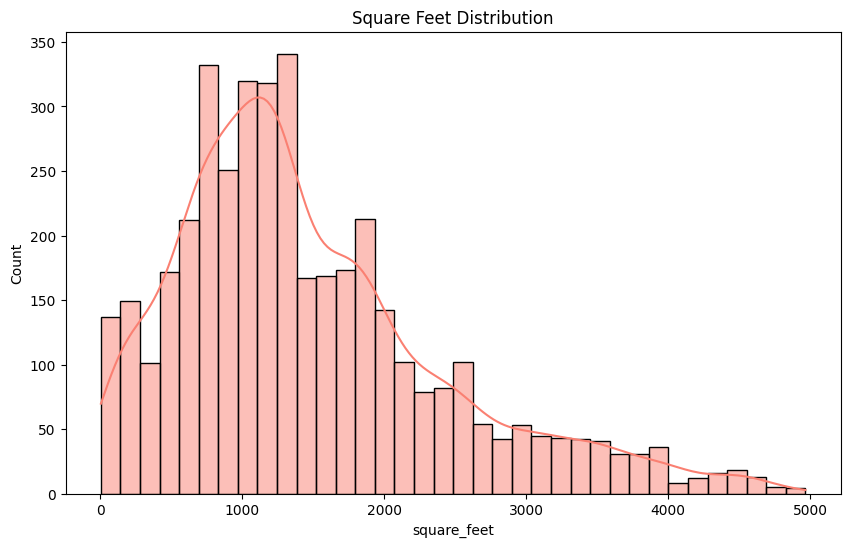

In [22]:
# 1. توزيع الأسعار (Price Distribution)
plt.figure(figsize=(10, 6))
sns.histplot(df['price (₹ Lac)'], kde=True, color='skyblue')
plt.title('(Distribution of Prices)')
plt.xlabel('Price (₹ Lac)')
plt.ylabel('Count')
plt.show()

# 2. توزيع المساحات (Square Feet Distribution)
# سنقوم بتحديد حد أقصى للمساحة في الرسم لأن القيم الشاذة قد تخفي التفاصيل
plt.figure(figsize=(10, 6))
sns.histplot(df[df['square_feet'] < 5000]['square_feet'], kde=True, color='salmon')
plt.title('Square Feet Distribution')
plt.show()

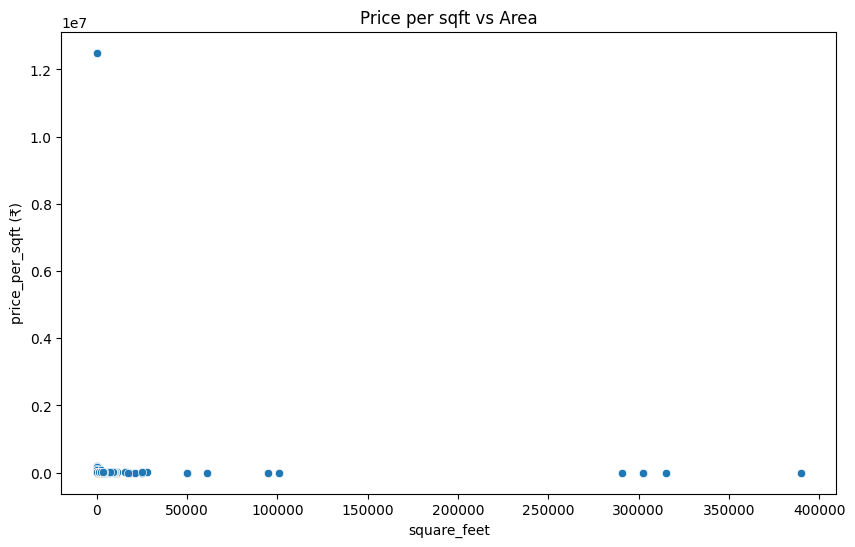

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='square_feet', y='price_per_sqft (₹)')
plt.title("Price per sqft vs Area")
plt.show()


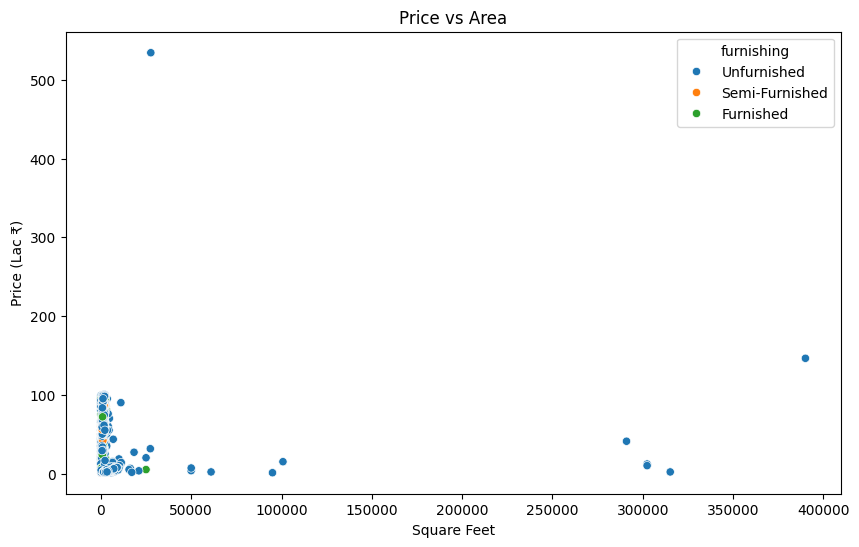

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='square_feet', y='price (₹ Lac)', hue='furnishing')
plt.title("Price vs Area")
plt.xlabel("Square Feet")
plt.ylabel("Price (Lac ₹)")
plt.show()


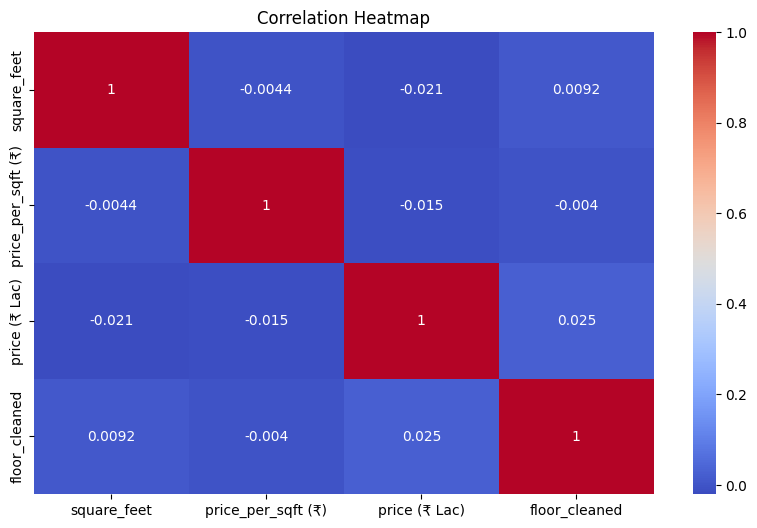

In [25]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


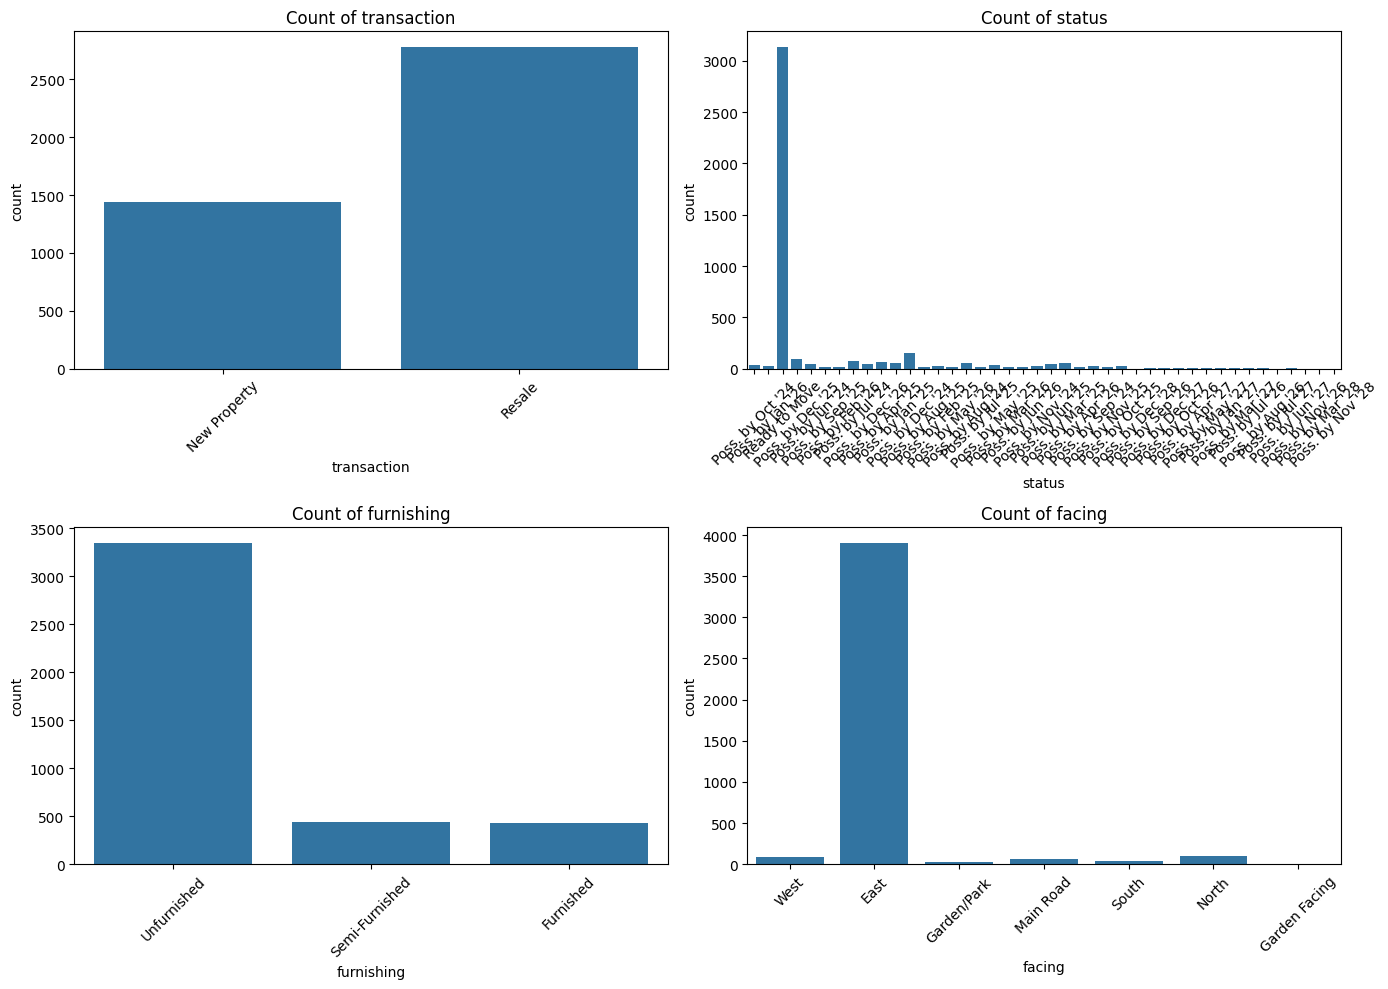

In [26]:
cat_cols = ['transaction', 'status', 'furnishing', 'facing']
plt.figure(figsize=(14,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)  # صفين، عمودين
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


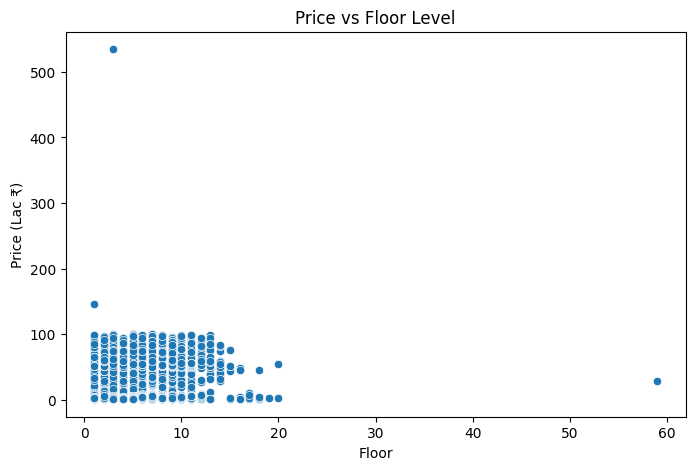

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='floor_cleaned', y='price (₹ Lac)')
plt.title("Price vs Floor Level")
plt.xlabel("Floor")
plt.ylabel("Price (Lac ₹)")
plt.show()


In [29]:


# متوسط السعر لكل نوع الصفقة
print(df.groupby('transaction')['price_per_sqft (₹)'].mean())
#Resale properties have a price per sqft almost twice as high as New Properties.

# متوسط السعر حسب المفروشات
print(df.groupby('furnishing')['price_per_sqft (₹)'].mean())
#Interestingly, unfurnished apartments have a much higher price per sqft compared to semi-furnished or fully furnished ones.

#The bar charts show that Resale properties are more common than New Properties,
# and Unfurnished units are the most frequent category.
#Because these two categories have the highest counts,
# and they often include larger or premium apartments, their average price per square foot is also higher.


count_by_facing = df.groupby('facing').size()
print("\nCount of Properties by Facing:")
print(count_by_facing)

price_by_floor = df.groupby('floor_cleaned')['price (₹ Lac)'].mean()
print("\nAverage Price by Floor:")
print(price_by_floor)
#Prices generally increase for mid-to-higher floors (6th–14th)
#Peak average price is on floor 14
# (6th–14th)Floors 16–19 show extremely low values,

pps_by_status = df.groupby('status')['price_per_sqft (₹)'].mean()
print("\nAvg Price Per Sqft by Status:")
print(pps_by_status)
#Ready to Move properties have the highest price per sqft (₹10,608)


transaction
New Property     5411.853064
Resale          11207.007565
Name: price_per_sqft (₹), dtype: float64
furnishing
Furnished          5232.416862
Semi-Furnished     5130.789954
Unfurnished       10278.023902
Name: price_per_sqft (₹), dtype: float64

Count of Properties by Facing:
facing
East             3903
Garden Facing       2
Garden/Park        26
Main Road          58
North              95
South              35
West               93
dtype: int64

Average Price by Floor:
floor_cleaned
1     33.097571
2     34.601603
3     35.035697
4     33.148243
5     31.723361
6     39.528311
7     36.199695
8     37.271154
9     37.450409
10    32.312124
11    42.352297
12    36.866275
13    39.447222
14    49.200000
15    31.070000
16    15.480000
17     5.648000
18     9.176667
19     3.265000
20    28.850000
59    29.000000
Name: price (₹ Lac), dtype: float64

Avg Price Per Sqft by Status:
status
Poss. by Apr '25     4987.304348
Poss. by Apr '26     4703.615385
Poss. by Apr '27     65

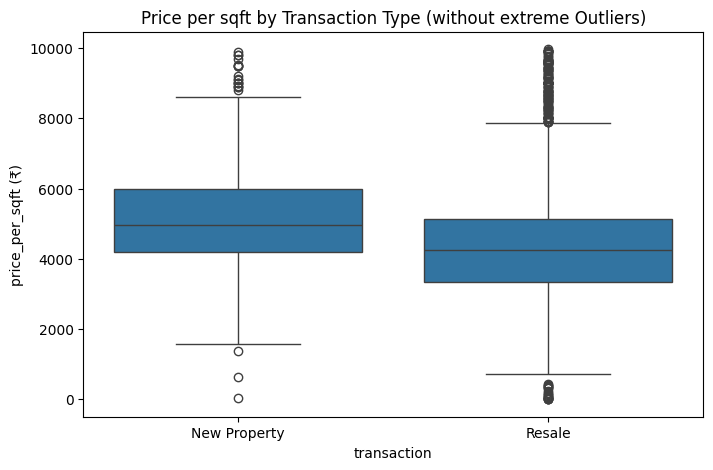

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# نفلتر الـ Outliers اللي أكبر من مثلاً 10000 ₹/sqft
df_filtered = df[df['price_per_sqft (₹)'] < 10000]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_filtered, x='transaction', y='price_per_sqft (₹)')
plt.title('Price per sqft by Transaction Type (without extreme Outliers)')
plt.show()
#New properties have a higher median price per square foot compared to resale properties.